### Imports and Configuration


In [1]:
# Import shared libraries, metrics, and utilities used throughout the TON_IoT modeling workflow.
# Keep metric imports centralized so split evaluation and cross-validation use consistent definitions.
# Configure warnings once to keep long experimental output readable during repeated reruns.

import numpy as np
import pandas as pd
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, fbeta_score, roc_auc_score,
                              average_precision_score)
from sklearn.model_selection import StratifiedKFold, cross_validate

### Paths and Data Loading


In [2]:
# Build project-relative paths to keep the notebook portable across environments and machines.
# Load the prepared TON_IoT train/validation/test splits so each model is evaluated on the same partitions.
# Ensure output directories exist before training so artifact persistence does not fail at the end.

from pathlib import Path
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

NOTEBOOK_DIR =  Path('/content/drive/MyDrive/MLmodeling/XAI/notebooks_v1')
BASE_DIR     = Path('/content/drive/MyDrive/MLmodeling/XAI')
DATASET_DIR  = BASE_DIR / 'Datasets' / 'TON_IOT'
SPLITS_DIR   = BASE_DIR / 'splits' / 'TON_IoT'
MODEL_DIR    = BASE_DIR / 'models' / 'TON_IoT'
RESULT_DIR   = BASE_DIR / 'results' / 'TON_IoT'
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(SPLITS_DIR / 'X_train_proc.npy')
X_val   = np.load(SPLITS_DIR / 'X_val_proc.npy')
X_test  = np.load(SPLITS_DIR / 'X_test_proc.npy')

y_train = pd.read_csv(SPLITS_DIR / 'y_train.csv').squeeze()
y_val   = pd.read_csv(SPLITS_DIR / 'y_val.csv').squeeze()
y_test  = pd.read_csv(SPLITS_DIR / 'y_test.csv').squeeze()

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Mounted at /content/drive
Train: (147724, 98) | Val: (31662, 98) | Test: (31657, 98)


### Model Definition


In [3]:
# Define MLP with explicit hyperparameters so this experiment remains reproducible and comparable.
# Keep model initialization isolated from training/evaluation so tuning edits stay localized.
# `random_state=42` is set to reduce run-to-run variance and keep benchmark comparisons fair.

# TON_13
from sklearn.neural_network import MLPClassifier
ARTIFACT_NAME = "TON_13_MLP"
MODEL_NAME = "MLP"
model = MLPClassifier(max_iter=300, random_state=42)

### Train and Evaluate


In [4]:
# Fit the model and evaluate train/validation/test in one flow to expose overfitting or underfitting quickly.
# Report threshold metrics (accuracy, precision, recall, F1, F2) and ranking metrics (ROC-AUC, PR-AUC).
# PR-AUC is especially useful when attack classes are imbalanced, so it complements ROC-AUC here.

# Train
model.fit(X_train, y_train)

# Evaluate function
def evaluate(model, X, y, split_name):
    y_pred = model.predict(X)
    y_prob = (model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba")
              else model.decision_function(X) if hasattr(model, "decision_function")
              else None)
    return {
        "split":     split_name,
        "accuracy":  round(accuracy_score(y, y_pred), 6),
        "precision": round(precision_score(y, y_pred, zero_division=0), 6),
        "recall":    round(recall_score(y, y_pred, zero_division=0), 6),
        "f1":        round(f1_score(y, y_pred, zero_division=0), 6),
        "f2":        round(fbeta_score(y, y_pred, beta=2, zero_division=0), 6),
        "roc_auc":   round(roc_auc_score(y, y_prob), 6) if y_prob is not None else None,
        "pr_auc":    round(average_precision_score(y, y_prob), 6) if y_prob is not None else None,
    }

train_m = evaluate(model, X_train, y_train, "train")
val_m   = evaluate(model, X_val,   y_val,   "val")
test_m  = evaluate(model, X_test,  y_test,  "test")

train_test_gap = round(train_m['f1'] - test_m['f1'], 6)
train_val_gap  = round(train_m['f1'] - val_m['f1'],  6)

print(f"Train    F1: {train_m['f1']:.4f} | ROC-AUC: {train_m['roc_auc']}")
print(f"Val      F1: {val_m['f1']:.4f}   | ROC-AUC: {val_m['roc_auc']}")
print(f"Test     F1: {test_m['f1']:.4f}  | ROC-AUC: {test_m['roc_auc']}")
print(f"Train-Val Gap:  {train_val_gap:.4f}")
print(f"Train-Test Gap: {train_test_gap:.4f}")

Train    F1: 0.9965 | ROC-AUC: 0.999486
Val      F1: 0.9968   | ROC-AUC: 0.999382
Test     F1: 0.9963  | ROC-AUC: 0.999421
Train-Val Gap:  -0.0003
Train-Test Gap: 0.0002


### Cross-Validation (5-Fold Stratified)


In [5]:
# Use stratified 5-fold cross-validation to estimate generalization more robustly than a single split.
# Fold-level train/validation metrics reveal variance and train-vs-validation gaps across folds.
# Parallel execution is enabled for speed; set `n_jobs=1` only if system memory becomes constrained.

from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

# Ã¢â€â‚¬Ã¢â€â‚¬ Sample 30% of training data for CV (MLP is memory-heavy)
from sklearn.model_selection import train_test_split

X_cv, _, y_cv, _ = train_test_split(
    X_train, y_train,
    train_size=0.70,
    random_state=42,
    stratify=y_train
)
print(f"CV sample size: {X_cv.shape[0]} rows (30% of train)")

# Ã¢â€â‚¬Ã¢â€â‚¬ 5-Fold Stratified CV on sample
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv  = cross_validate(model, X_cv, y_cv, cv=skf,
                     scoring=['f1', 'roc_auc', 'average_precision'],
                     return_train_score=True,
                     n_jobs=1)          # n_jobs=1 for MLP   parallel copies multiply RAM usage

cv_results = {
    "cv_train_f1_mean": round(cv['train_f1'].mean(), 6),
    "cv_val_f1_mean":   round(cv['test_f1'].mean(),  6),
    "cv_val_f1_std":    round(cv['test_f1'].std(),   6),
    "cv_val_roc_mean":  round(cv['test_roc_auc'].mean(), 6),
    "cv_val_pr_mean":   round(cv['test_average_precision'].mean(), 6),
    "cv_gap":           round(cv['train_f1'].mean() - cv['test_f1'].mean(), 6),
}

print(f"CV Val F1:  {cv_results['cv_val_f1_mean']:.4f} Ã‚Â± {cv_results['cv_val_f1_std']:.4f}")
print(f"CV Gap:     {cv_results['cv_gap']:.4f}")
print("Note: CV run on 30% stratified sample due to MLP memory constraints")

CV sample size: 103406 rows (30% of train)
CV Val F1:  0.9966 Ã‚Â± 0.0004
CV Gap:     0.0003
Note: CV run on 30% stratified sample due to MLP memory constraints


### Save Results and Model Artifact


In [6]:
# Assemble a standardized result row so this notebook matches the shared benchmarking schema.
# Save this notebook's latest metrics snapshot to CSV (default `to_csv` overwrites on rerun).
# Persist the trained model artifact for downstream interpretability workflows such as SHAP and LIME.

# Save results and model artifacts for downstream analysis
# Why: persist metrics for analysis and save a serialized model to reproduce predictions or resume experiments.
row = {
    "dataset":         "TON_IoT",
    "model":           MODEL_NAME,
    "split":           "70/15/15",
    "test_accuracy":   test_m['accuracy'],
    "test_precision":  test_m['precision'],
    "test_recall":     test_m['recall'],
    "test_f1":         test_m['f1'],
    "test_f2":         test_m['f2'],
    "test_roc_auc":    test_m['roc_auc'],
    "test_pr_auc":     test_m['pr_auc'],
    "val_f1":          val_m['f1'],
    "val_f2":          val_m['f2'],
    "val_roc_auc":     val_m['roc_auc'],
    "val_pr_auc":      val_m['pr_auc'],
    "train_f1":        train_m['f1'],
    "cv_val_f1_mean":  cv_results['cv_val_f1_mean'],
    "cv_val_f1_std":   cv_results['cv_val_f1_std'],
    "cv_val_roc_mean": cv_results['cv_val_roc_mean'],
    "cv_val_pr_mean":  cv_results['cv_val_pr_mean'],
    "cv_gap":          cv_results['cv_gap'],
    "train_test_gap":  train_test_gap,
}

pd.DataFrame([row]).to_csv(f"{RESULT_DIR}//{ARTIFACT_NAME}.csv", index=False)
joblib.dump(model, f"{MODEL_DIR}//{ARTIFACT_NAME}.pkl")

print(f"{ARTIFACT_NAME}   saved.")
print(pd.DataFrame([row]).T.to_string(header=False))

TON_13_MLP   saved.
dataset           TON_IoT
model                 MLP
split            70/15/15
test_accuracy    0.994346
test_precision   0.994351
test_recall      0.998261
test_f1          0.996302
test_f2          0.997477
test_roc_auc     0.999421
test_pr_auc      0.999818
val_f1           0.996797
val_f2            0.99775
val_roc_auc      0.999382
val_pr_auc       0.999773
train_f1         0.996463
cv_val_f1_mean   0.996558
cv_val_f1_std    0.000438
cv_val_roc_mean  0.999085
cv_val_pr_mean   0.999527
cv_gap           0.000305
train_test_gap   0.000161


## Cell 7: Interactive Inference (Widgets)

Use the saved TON-IoT Logistic Regression artifact to run single-row predictions as **NORMAL** or **ATTACK**.


In [7]:
# Widget inference setup: load model + feature defaults + optional preprocessing artifacts.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Resolve project root robustly so this cell can run standalone.
cwd = Path('/content/drive/MyDrive/MLmodeling/XAI')
if (cwd / 'models').exists() and (cwd / 'features').exists():
    BASE_DIR = cwd
elif (cwd.parent / 'models').exists() and (cwd.parent / 'features').exists():
    BASE_DIR = cwd.parent
elif (Path('/content/drive/MyDrive/MLmodeling/XAI') / 'models').exists() and (Path('/content/drive/MyDrive/MLmodeling/XAI') / 'features').exists():
    BASE_DIR = Path('/content/drive/MyDrive/MLmodeling/XAI')
else:
    BASE_DIR = cwd

FEATURES_FILE = BASE_DIR / 'features' / 'TON_IoT_features.json'
MODEL_FILE = BASE_DIR / 'models' / 'TON_IoT' / 'TON_13_MLP.pkl'
SPLIT_DIR = BASE_DIR / 'splits' / 'TON_IoT'

assert FEATURES_FILE.exists(), f'Feature defaults not found: {FEATURES_FILE}'
assert MODEL_FILE.exists(), f'Model file not found: {MODEL_FILE}'

with open(FEATURES_FILE, 'r', encoding='utf-8') as f:
    TON_DEFAULTS = json.load(f)

# Exclude non-predictive raw columns if they still exist in feature JSON.
EXCLUDE_COLS = {
    'label', 'type', 'src_ip', 'dst_ip', 'dns_query', 'ssl_subject',
    'ssl_issuer', 'http_uri', 'http_user_agent', 'http_orig_mime_types',
    'http_resp_mime_types', 'weird_addl'
}
TON_DEFAULTS = {k: v for k, v in TON_DEFAULTS.items() if k not in EXCLUDE_COLS}

INFER_MODEL = joblib.load(MODEL_FILE)

INFER_PREPROCESSOR = None
for pp_name in ('preprocessor.joblib', 'preprocessor.pkl'):
    pp_path = SPLIT_DIR / pp_name
    if pp_path.exists():
        INFER_PREPROCESSOR = joblib.load(pp_path)
        break

INFER_FEATURE_NAMES = None
fn_path = SPLIT_DIR / 'feature_names.csv'
if fn_path.exists():
    INFER_FEATURE_NAMES = pd.read_csv(fn_path, header=None).squeeze().tolist()

print(f'Loaded model: {MODEL_FILE.name}')
print(f'Feature defaults: {len(TON_DEFAULTS)}')
print(f'Preprocessor loaded: {INFER_PREPROCESSOR is not None}')


Loaded model: TON_13_MLP.pkl
Feature defaults: 32
Preprocessor loaded: True


In [8]:
# Build interactive input form and predict NORMAL/ATTACK.
if 'TON_DEFAULTS' not in globals():
    print('Run the previous widget setup cell first.')
else:
    input_widgets = {}

    CAT_OPTIONS = {
        'proto': ['tcp', 'udp', 'icmp', 'arp', 'ospf', 'sctp', 'gre', 'igmp', 'unas', 'any', 'ip', 'ipnip', 'rsvp', 'pim', 'mobile', 'swipe', 'sep', 'sun-nd', 'rtp', '-'],
        'service': ['-', 'http', 'ftp', 'ftp-data', 'smtp', 'pop3', 'dns', 'snmp', 'ssl', 'dhcp', 'irc', 'ssh', 'radius', 'mqtt', 'ntp'],
        'state': ['INT', 'FIN', 'REQ', 'ACC', 'CON', 'RST', 'CLO'],
        'conn_state': ['S0', 'S1', 'SF', 'REJ', 'S2', 'S3', 'RSTO', 'RSTR', 'RSTOS0', 'RSTRH', 'SH', 'SHR', 'OTH'],
        'dns_AA': ['-', 'T', 'F'],
        'dns_RD': ['-', 'T', 'F'],
        'dns_RA': ['-', 'T', 'F'],
        'dns_rejected': ['-', 'T', 'F'],
        'ssl_version': ['-', 'TLSv10', 'TLSv11', 'TLSv12', 'SSLv2', 'SSLv3'],
        'ssl_cipher': ['-', 'TLS_RSA_WITH_AES_128_CBC_SHA', 'ECDHE-RSA-AES256-SHA'],
        'ssl_resumed': ['-', 'T', 'F'],
        'ssl_established': ['-', 'T', 'F'],
        'http_trans_depth': ['-', '1', '2', '3'],
        'http_method': ['-', 'GET', 'POST', 'HEAD', 'PUT', 'DELETE'],
        'http_version': ['-', '1.0', '1.1', '2.0'],
        'weird_name': ['-', 'line_terminated_with_single_CR', 'data_before_established', 'unknown_HTTP_method'],
        'weird_notice': ['-', 'T', 'F'],
    }

    def make_widget(col, default):
        if isinstance(default, str) or col in CAT_OPTIONS:
            opts = CAT_OPTIONS.get(col, [])
            if str(default) not in [str(o) for o in opts]:
                opts = [str(default)] + opts
            return widgets.Dropdown(
                options=opts if opts else [str(default)],
                value=str(default),
                layout=widgets.Layout(width='360px', min_width='300px', height='34px')
            )
        if isinstance(default, int) and not isinstance(default, bool):
            return widgets.IntText(value=int(default), layout=widgets.Layout(width='360px', min_width='300px', height='34px'))
        return widgets.FloatText(value=float(default), step=0.01, layout=widgets.Layout(width='360px', min_width='300px', height='34px'))

    def to_group_name(col_name):
        if '.' in col_name:
            return col_name.split('.', 1)[0]
        if '_' in col_name:
            return col_name.split('_', 1)[0]
        return 'other'

    feature_groups = {}
    for col, default in TON_DEFAULTS.items():
        w = make_widget(col, default)
        input_widgets[col] = w
        group = to_group_name(col)
        feature_groups.setdefault(group, []).append(col)

    sorted_groups = sorted(feature_groups.keys())
    group_boxes = []

    for group in sorted_groups:
        rows = []
        for col in feature_groups[group]:
            label = widgets.HTML(
                value=f'<div style="font-family:monospace; font-size:13px;">{col}</div>',
                layout=widgets.Layout(width='430px', min_width='360px')
            )
            rows.append(
                widgets.HBox(
                    [label, input_widgets[col]],
                    layout=widgets.Layout(justify_content='space-between', width='100%')
                )
            )

        group_box = widgets.VBox(rows, layout=widgets.Layout(gap='8px', padding='8px 4px'))
        group_boxes.append(group_box)

    accordion = widgets.Accordion(
        children=group_boxes,
        layout=widgets.Layout(width='100%', max_height='560px', overflow_y='auto')
    )

    for i, group in enumerate(sorted_groups):
        accordion.set_title(i, f'{group} ({len(feature_groups[group])})')

    if sorted_groups:
        accordion.selected_index = 0

    group_selector = widgets.Dropdown(
        options=[(f'{g} ({len(feature_groups[g])})', i) for i, g in enumerate(sorted_groups)],
        description='Jump to:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='360px')
    )

    search_box = widgets.Text(
        value='',
        placeholder='Type feature name (e.g., proto, flow, dns) then press Enter',
        description='Find:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='620px')
    )

    predict_btn = widgets.Button(
        description='Predict',
        button_style='success',
        icon='check',
        layout=widgets.Layout(width='130px', height='36px')
    )
    reset_btn = widgets.Button(
        description='Reset',
        icon='refresh',
        layout=widgets.Layout(width='110px', height='36px')
    )

    result_out = widgets.Output()

    def on_group_change(change):
        if change['name'] == 'value':
            accordion.selected_index = change['new']

    def on_find_submit(_):
        q = search_box.value.strip().lower()
        if not q:
            return
        for idx, group in enumerate(sorted_groups):
            for col in feature_groups[group]:
                if q in col.lower():
                    accordion.selected_index = idx
                    with result_out:
                        clear_output()
                        print(f'Found in group: {group}. Scroll to locate "{col}".')
                    return
        with result_out:
            clear_output()
            print(f'No feature matched "{q}".')

    group_selector.observe(on_group_change, names='value')
    search_box.on_submit(on_find_submit)

    def _build_input_row():
        row = {}
        for c, d in TON_DEFAULTS.items():
            v = input_widgets[c].value
            if isinstance(d, str) or c in CAT_OPTIONS:
                row[c] = str(v)
            elif isinstance(d, int) and not isinstance(d, bool):
                row[c] = int(v)
            else:
                row[c] = float(v)
        return row

    def _prepare_X(df_input):
        X_proc = None
        if INFER_PREPROCESSOR is not None:
            X_proc = INFER_PREPROCESSOR.transform(df_input)

        if X_proc is None:
            expected_n = getattr(INFER_MODEL, 'n_features_in_', None)
            if INFER_FEATURE_NAMES is not None and (expected_n is None or len(INFER_FEATURE_NAMES) == int(expected_n)):
                X_proc = df_input.reindex(columns=[str(c) for c in INFER_FEATURE_NAMES], fill_value=0).astype(float).values
            elif hasattr(INFER_MODEL, 'feature_names_in_'):
                model_cols = [str(c) for c in INFER_MODEL.feature_names_in_]
                X_proc = df_input.reindex(columns=model_cols, fill_value=0).astype(float).values
            else:
                X_proc = df_input.select_dtypes(include=[np.number]).values

        expected_n = getattr(INFER_MODEL, 'n_features_in_', None)
        if expected_n is not None and X_proc.shape[1] != int(expected_n):
            if X_proc.shape[1] > int(expected_n):
                X_proc = np.asarray(X_proc)[:, :int(expected_n)]
            else:
                raise ValueError(f'Feature mismatch: expected {int(expected_n)}, got {X_proc.shape[1]}')

        if hasattr(INFER_MODEL, 'feature_names_in_') and X_proc.shape[1] == len(INFER_MODEL.feature_names_in_):
            return pd.DataFrame(X_proc, columns=[str(c) for c in INFER_MODEL.feature_names_in_])
        return X_proc

    def on_predict(_):
        with result_out:
            clear_output()
            try:
                row = _build_input_row()
                df_input = pd.DataFrame([row])
                X_input = _prepare_X(df_input)

                pred = int(INFER_MODEL.predict(X_input)[0])
                label = 'ATTACK' if pred == 1 else 'NORMAL'
                color = '#d32f2f' if pred == 1 else '#388e3c'

                score_html = ''
                if hasattr(INFER_MODEL, 'predict_proba'):
                    p = INFER_MODEL.predict_proba(X_input)[0]
                    normal_score = float(p[0])
                    attack_score = float(p[1])
                    pred_score = attack_score if pred == 1 else normal_score
                    score_html = (
                        f"<div style='margin-top:8px;font-size:14px;color:#444;'>"
                        f"normal_score={normal_score:.4f} | attack_score={attack_score:.4f} | "
                        f"prediction_confidence={pred_score:.4f}</div>"
                    )
                elif hasattr(INFER_MODEL, 'decision_function'):
                    decision_score = float(np.ravel(INFER_MODEL.decision_function(X_input))[0])
                    score_html = f"<div style='margin-top:8px;font-size:14px;color:#444;'>decision_score={decision_score:.6f}</div>"

                display(HTML(f"""
                    <div style='border:2px solid {color}; border-radius:8px; padding:14px; max-width:700px;'>
                        <div style='font-size:22px; font-weight:700; color:{color};'>Prediction: {label}</div>
                        <div style='margin-top:6px; font-size:13px; color:#666;'>Dataset: TON_IoT | Model: MLP</div>
                        {score_html}
                    </div>
                """))
            except Exception as e:
                print(f'Prediction failed: {e}')

    def on_reset(_):
        for c, d in TON_DEFAULTS.items():
            input_widgets[c].value = d
        with result_out:
            clear_output()
            print('Inputs reset to TON_IoT feature defaults.')

    predict_btn.on_click(on_predict)
    reset_btn.on_click(on_reset)

    controls = widgets.HBox(
        [group_selector, predict_btn, reset_btn],
        layout=widgets.Layout(gap='10px', align_items='center')
    )

    display(widgets.VBox([
        widgets.HTML('<h3 style="margin:0;">TON-IoT Interactive Inference</h3>'),
        widgets.HTML('<div style="color:#555;">Edit values below and click Predict to classify as NORMAL or ATTACK.</div>'),
        search_box,
        controls,
        accordion,
        result_out
    ], layout=widgets.Layout(gap='10px', width='100%')))


## Cell 8: XAI Analysis (SHAP + LIME + Rule Diagrams)

This section mirrors the structured explainability workflow with global/local SHAP, rule-style analysis, stability/fidelity metrics, and LIME visuals.


In [9]:
# STEP 1: XAI imports + readiness checks (standalone-friendly)
import sys
import subprocess
import time
from pathlib import Path

try:
    import shap
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])
    import shap

try:
    import lime
    import lime.lime_tabular
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime'])
    import lime
    import lime.lime_tabular

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# If training variables are not present, load from saved artifacts/splits.
required = ['model', 'X_train', 'X_test', 'y_test']
missing = [k for k in required if k not in globals()]
if missing:
    cwd = Path('/content/drive/MyDrive/MLmodeling/XAI')
    if (cwd / 'models').exists() and (cwd / 'features').exists():
        BASE_DIR = cwd
    elif (cwd.parent / 'models').exists() and (cwd.parent / 'features').exists():
        BASE_DIR = cwd.parent
    elif (Path('/content/drive/MyDrive/MLmodeling/XAI') / 'models').exists() and (Path('/content/drive/MyDrive/MLmodeling/XAI') / 'splits').exists():
        BASE_DIR = Path('/content/drive/MyDrive/MLmodeling/XAI')
    else:
        BASE_DIR = cwd

    SPLITS_DIR = BASE_DIR / 'splits' / 'TON_IoT'
    MODEL_DIR = BASE_DIR / 'models' / 'TON_IoT'

    if 'X_train' not in globals():
        npy_train = SPLITS_DIR / 'X_train_proc.npy'
        csv_train = SPLITS_DIR / 'X_train.csv'
        if npy_train.exists():
            X_train = np.load(npy_train)
        elif csv_train.exists():
            X_train = pd.read_csv(csv_train).values
        else:
            raise FileNotFoundError(f'Could not find X_train in {SPLITS_DIR}')

    if 'X_test' not in globals():
        npy_test = SPLITS_DIR / 'X_test_proc.npy'
        csv_test = SPLITS_DIR / 'X_test.csv'
        if npy_test.exists():
            X_test = np.load(npy_test)
        elif csv_test.exists():
            X_test = pd.read_csv(csv_test).values
        else:
            raise FileNotFoundError(f'Could not find X_test in {SPLITS_DIR}')

    if 'y_test' not in globals():
        y_test_file = SPLITS_DIR / 'y_test.csv'
        if y_test_file.exists():
            y_test = pd.read_csv(y_test_file).squeeze()
        else:
            raise FileNotFoundError(f'Could not find y_test.csv in {SPLITS_DIR}')

    if 'model' not in globals():
        model_file = MODEL_DIR / 'TON_13_MLP.pkl'
        if not model_file.exists():
            raise FileNotFoundError(f'Model artifact missing: {model_file}')
        model = joblib.load(model_file)

    if 'MODEL_NAME' not in globals():
        MODEL_NAME = 'MLP'

    if 'ARTIFACT_NAME' not in globals():
        ARTIFACT_NAME = 'TON_13_MLP'

    if 'RESULT_DIR' not in globals():
        RESULT_DIR = BASE_DIR / 'results' / 'TON_IoT'
        RESULT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')
np.random.seed(42)
print('XAI dependencies/data ready.')
print(f'X_train: {np.shape(X_train)} | X_test: {np.shape(X_test)} | y_test: {len(y_test)}')


XAI dependencies/data ready.
X_train: (147724, 98) | X_test: (31657, 98) | y_test: 31657


PermutationExplainer explainer: 1001it [02:57,  5.62it/s]


Top SHAP features:
            feature  mean_abs_shap
      num__dst_port       0.092376
     cat__proto_udp       0.062506
   cat__service_dns       0.058714
     cat__proto_tcp       0.054303
cat__dns_rejected_F       0.046095
cat__conn_state_REJ       0.039537
      num__src_port       0.032122
     cat__service_-       0.026310
      num__src_pkts       0.023497
     num__dns_qtype       0.017846
 cat__conn_state_S0       0.017409
      cat__dns_RD_F       0.015314
 cat__conn_state_SF       0.014746
      cat__dns_AA_-       0.013094
      cat__dns_RA_-       0.012050


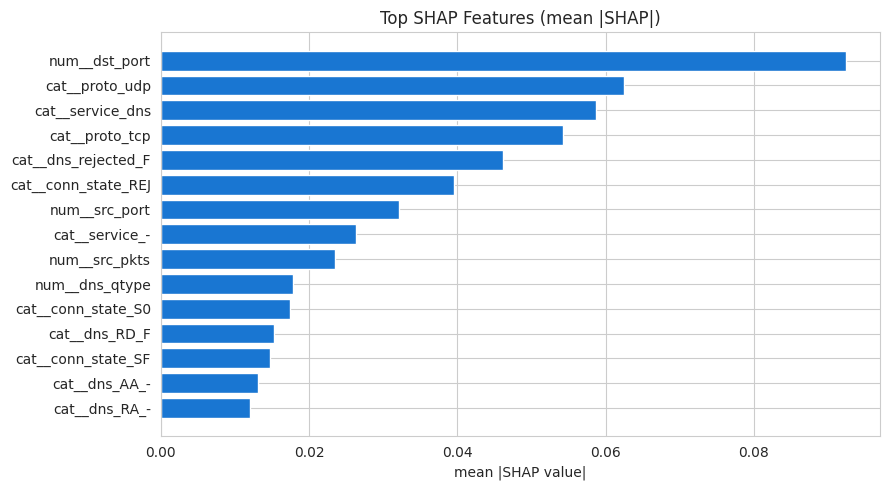

SHAP explanation time: 177.999s
SHAP summary plot:


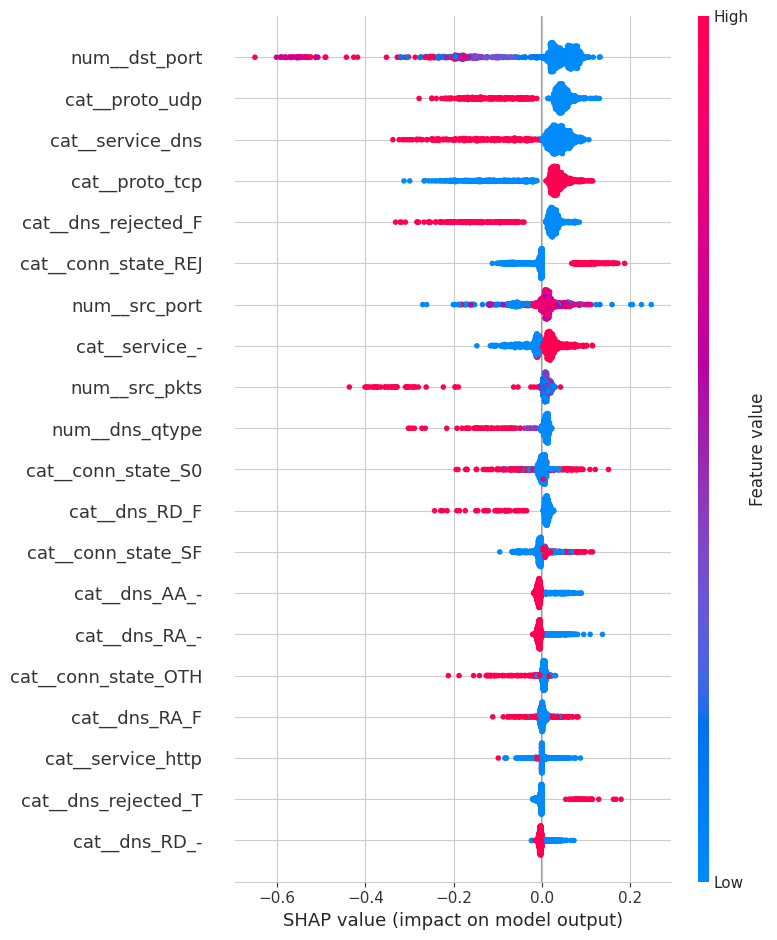

SHAP bar summary plot:


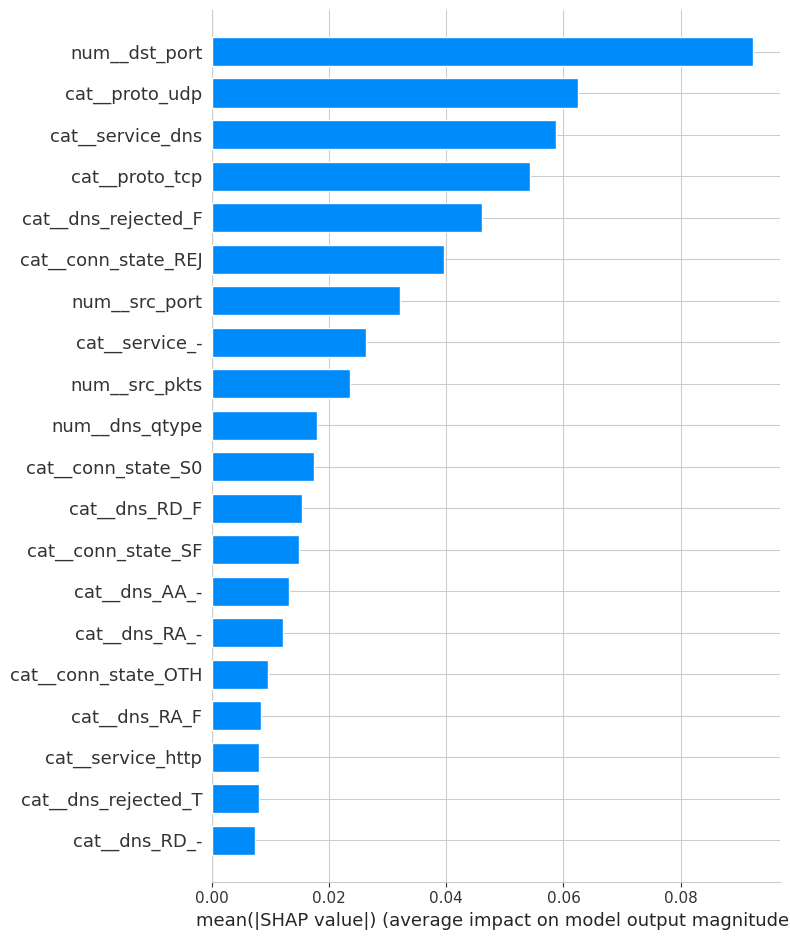

Local SHAP (predicted ATTACK) at sampled index 1


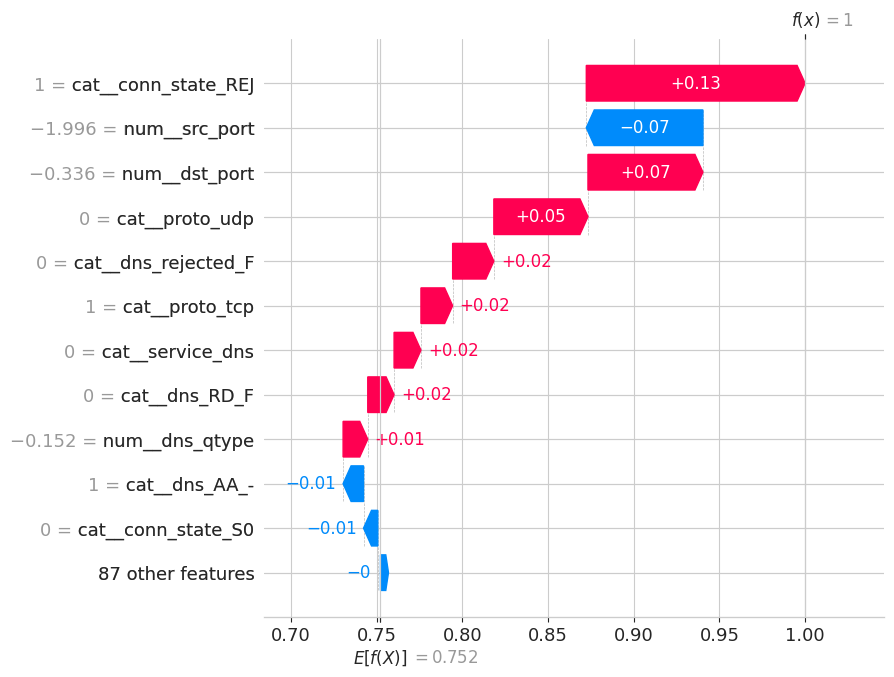

Local SHAP (predicted NORMAL) at sampled index 0


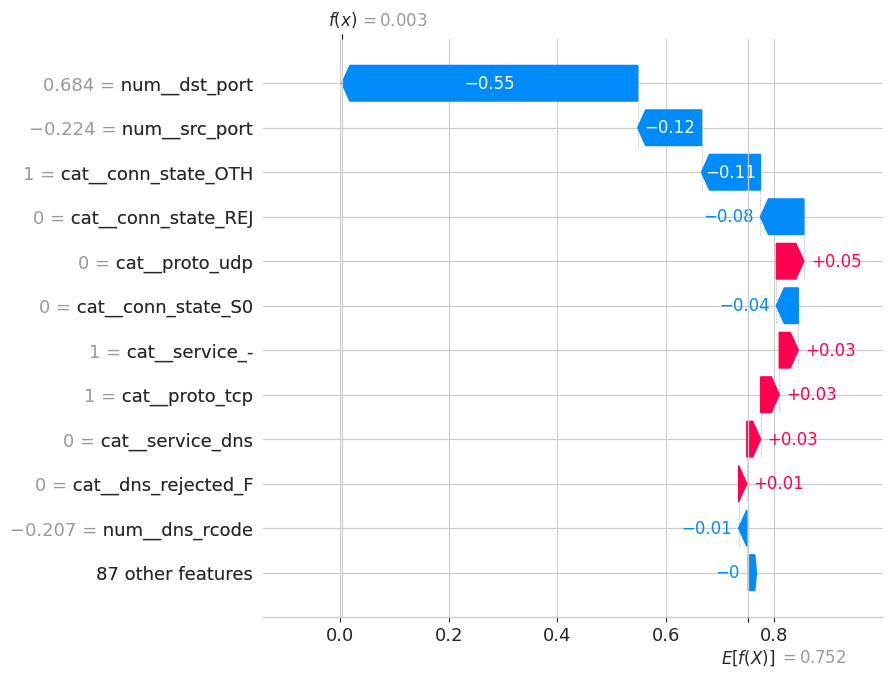

In [10]:
# STEP 2: SHAP global + local analysis and diagrams
# Use real processed feature names when available (same idea as inference_xai).
feature_names = None

# 1. Try INFER_FEATURE_NAMES from widget setup (if feature_names.csv existed)
if 'INFER_FEATURE_NAMES' in globals() and INFER_FEATURE_NAMES is not None and len(INFER_FEATURE_NAMES) == X_train.shape[1]:
    feature_names = [str(c) for c in INFER_FEATURE_NAMES]

# 2. Try model.feature_names_in_ (unlikely for current model/X_train type)
elif hasattr(model, 'feature_names_in_') and len(getattr(model, 'feature_names_in_', [])) == X_train.shape[1]:
    feature_names = [str(c) for c in model.feature_names_in_]

# 3. Try deriving from INFER_PREPROCESSOR and TON_DEFAULTS (loaded in previous cell)
elif 'INFER_PREPROCESSOR' in globals() and INFER_PREPROCESSOR is not None and \
     'TON_DEFAULTS' in globals() and TON_DEFAULTS is not None:
    try:
        _raw_input_cols = list(TON_DEFAULTS.keys())
        _derived_feature_names = INFER_PREPROCESSOR.get_feature_names_out(_raw_input_cols).tolist()
        if len(_derived_feature_names) == X_train.shape[1]:
            feature_names = [str(c) for c in _derived_feature_names]
        else:
            print(f"Warning: INFER_PREPROCESSOR.get_feature_names_out() returned {len(_derived_feature_names)} features, but X_train has {X_train.shape[1]}.")
    except Exception as e:
        print(f"Warning: Failed to derive feature names from INFER_PREPROCESSOR using TON_DEFAULTS: {e}")
        pass # feature_names remains None

# 4. Fallback to trying to load from splits directory (original else block logic)
if feature_names is None: # Only execute this block if feature_names is still None
    try:
        cwd = Path.cwd()
        if (cwd / 'splits').exists():
            _base = cwd
        elif (cwd.parent / 'splits').exists():
            _base = cwd.parent
        elif len(cwd.parents) > 1 and (cwd.parents[1] / 'splits').exists():
            _base = cwd.parents[1]
        else:
            _base = cwd

        _split_dir = _base / 'splits' / 'TON_IoT'

        # a) direct names file if present
        _fn_path = _split_dir / 'feature_names.csv'
        if _fn_path.exists():
            _loaded_names = pd.read_csv(_fn_path, header=None).squeeze().tolist()
            if len(_loaded_names) == X_train.shape[1]:
                feature_names = [str(c) for c in _loaded_names]

        # b) derive from fitted preprocessor using raw column order (if X_train.csv exists)
        if feature_names is None:
            _pp_path = _split_dir / 'preprocessor.pkl'
            _xraw_path = _split_dir / 'X_train.csv'
            if _pp_path.exists() and _xraw_path.exists():
                _pp = joblib.load(_pp_path)
                _raw_cols = pd.read_csv(_xraw_path, nrows=1).columns.tolist()
                try:
                    _derived = _pp.get_feature_names_out(_raw_cols).tolist()
                except Exception:
                    _derived = _pp.get_feature_names_out().tolist()

                if len(_derived) == X_train.shape[1]:
                    feature_names = [str(c) for c in _derived]
    except Exception as e:
        print(f"Warning: Fallback feature name derivation failed: {e}")
        pass # feature_names remains None

if feature_names is None:
    raise RuntimeError(
        'Could not resolve exact processed feature names for TON_IoT. '
        'Expected one of: INFER_FEATURE_NAMES, model.feature_names_in_, splits/TON_IoT/feature_names.csv, '
        'or derivation via splits/TON_IoT/preprocessor.pkl + X_train.csv.'
    )

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

bg_size = min(2000, len(X_train_df))
sample_size = min(1000, len(X_test_df))
bg_df = X_train_df.sample(bg_size, random_state=42)
X_sample = X_test_df.sample(sample_size, random_state=42)

t0 = time.time()
explainer = shap.Explainer(model.predict_proba, bg_df)
shap_exp = explainer(X_sample, check_additivity=False)
shap_time = round(time.time() - t0, 3)

# Normalize SHAP output to [n_samples, n_features]
sv_raw = np.asarray(shap_exp.values)
if sv_raw.ndim == 3:
    class_idx = 1 if sv_raw.shape[2] > 1 else 0
    sv = sv_raw[:, :, class_idx]
else:
    sv = sv_raw

mean_abs_shap = np.abs(sv).mean(axis=0)
mean_abs_shap = np.asarray(mean_abs_shap).reshape(-1)
shap_top_idx = np.argsort(mean_abs_shap)[::-1][:15]
shap_top_features = [feature_names[int(i)] for i in shap_top_idx]

shap_table = pd.DataFrame({
    'feature': shap_top_features,
    'mean_abs_shap': mean_abs_shap[shap_top_idx]
})
print('Top SHAP features:')
print(shap_table.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(shap_table['feature'][::-1], shap_table['mean_abs_shap'][::-1], color='#1976d2')
plt.title('Top SHAP Features (mean |SHAP|)')
plt.xlabel('mean |SHAP value|')
plt.tight_layout()
plt.show()

print(f'SHAP explanation time: {shap_time}s')
print('SHAP summary plot:')
shap.summary_plot(sv, X_sample, feature_names=feature_names, show=True)

print('SHAP bar summary plot:')
shap.summary_plot(sv, X_sample, feature_names=feature_names, plot_type='bar', show=True)

# Local explanation for one attack and one normal sample
y_pred_sample = model.predict(X_sample)
attack_idx = np.where(y_pred_sample == 1)[0]
normal_idx = np.where(y_pred_sample == 0)[0]

if len(attack_idx) > 0:
    i = int(attack_idx[0])
    print(f'Local SHAP (predicted ATTACK) at sampled index {i}')
    if np.asarray(shap_exp.values).ndim == 3:
        _class_idx = 1 if np.asarray(shap_exp.values).shape[2] > 1 else 0
        shap.plots.waterfall(shap_exp[i, :, _class_idx], max_display=12)
    else:
        shap.plots.waterfall(shap_exp[i], max_display=12)

if len(normal_idx) > 0:
    j = int(normal_idx[0])
    print(f'Local SHAP (predicted NORMAL) at sampled index {j}')
    if np.asarray(shap_exp.values).ndim == 3:
        _class_idx = 1 if np.asarray(shap_exp.values).shape[2] > 1 else 0
        shap.plots.waterfall(shap_exp[j, :, _class_idx], max_display=12)
    else:
        shap.plots.waterfall(shap_exp[j], max_display=12)

# Persist for later cells
XAI_CTX = {
    'feature_names': feature_names,
    'X_train_df': X_train_df,
    'X_test_df': X_test_df,
    'X_sample': X_sample,
    'shap_exp': shap_exp,
    'shap_values': sv,
    'shap_top_features': shap_top_features,
    'shap_time_sec': shap_time,
}


Top candidate SHAP-informed rules:
                        rule  coverage  precision_attack  support
cat__conn_state_REJ > 0.0000  0.216350          1.000000     6849
     num__dst_port > -0.2998  0.274252          0.578669     8682
     num__dst_port < -0.3381  0.239284          0.518944     7575
   cat__service_dns > 0.0000  0.187921          0.261388     5949
     cat__proto_tcp < 1.0000  0.201409          0.249216     6376
     cat__proto_udp > 0.0000  0.199987          0.246880     6331
cat__dns_rejected_F > 0.0000  0.138453          0.138946     4383
     cat__proto_udp < 0.0000  0.000000          0.000000        0
   cat__service_dns < 0.0000  0.000000          0.000000        0
     cat__proto_tcp > 1.0000  0.000000          0.000000        0
cat__dns_rejected_F < 0.0000  0.000000          0.000000        0
cat__conn_state_REJ < 0.0000  0.000000          0.000000        0


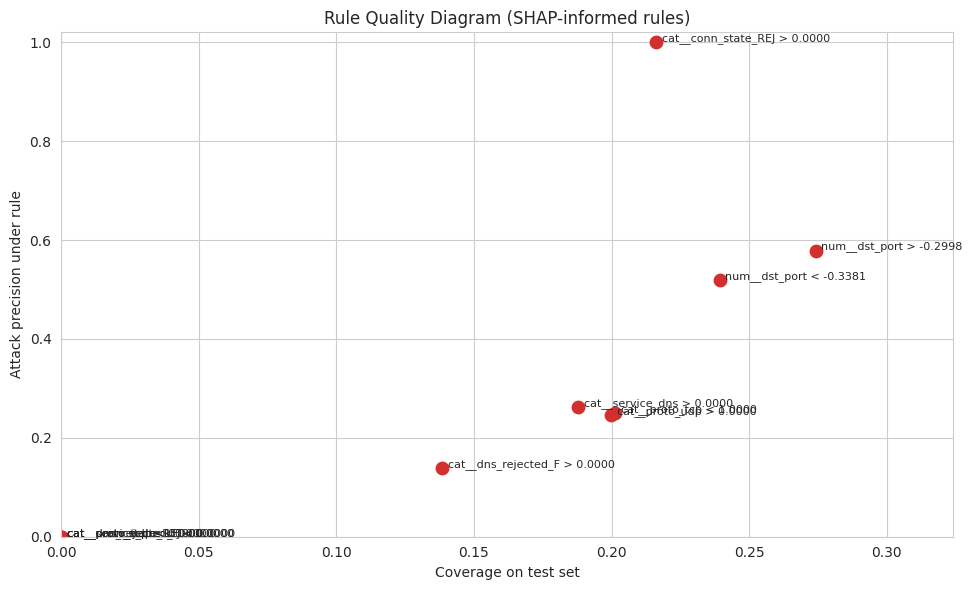


Best rule summary:
  rule: cat__conn_state_REJ > 0.0000
  coverage: 0.21635025428815113
  precision_attack: 1.0
  support: 6849


In [11]:
# STEP 3: SHAP-based manual rule drafting + rule diagrams
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

X_test_df = XAI_CTX['X_test_df']
feature_names = XAI_CTX['feature_names']
shap_values = XAI_CTX['shap_values']
X_sample = XAI_CTX['X_sample']

# Build candidate thresholds from top SHAP features using sampled quantiles.
mean_abs = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs)[::-1][:6]

def eval_rule(mask, y_true):
    coverage = float(mask.mean())
    if mask.sum() == 0:
        return {'coverage': 0.0, 'precision_attack': 0.0, 'support': 0}
    precision_attack = float((y_true[mask] == 1).mean())
    return {
        'coverage': coverage,
        'precision_attack': precision_attack,
        'support': int(mask.sum())
    }

rule_rows = []
y_test_arr = np.asarray(y_test)

for i in top_idx:
    f = feature_names[i]
    q75 = float(X_sample[f].quantile(0.75))
    q25 = float(X_sample[f].quantile(0.25))

    mask_hi = X_test_df[f].values > q75
    mask_lo = X_test_df[f].values < q25

    hi_m = eval_rule(mask_hi, y_test_arr)
    lo_m = eval_rule(mask_lo, y_test_arr)

    rule_rows.append({'rule': f'{f} > {q75:.4f}', **hi_m})
    rule_rows.append({'rule': f'{f} < {q25:.4f}', **lo_m})

rule_df = pd.DataFrame(rule_rows).sort_values(['precision_attack', 'coverage'], ascending=False)
print('Top candidate SHAP-informed rules:')
print(rule_df.head(12).to_string(index=False))

# Plot rule quality diagram (precision vs coverage)
plot_df = rule_df.head(12).copy()
plt.figure(figsize=(10, 6))
plt.scatter(plot_df['coverage'], plot_df['precision_attack'], s=80, c='#d32f2f')
for _, r in plot_df.iterrows():
    plt.text(r['coverage'] + 0.002, r['precision_attack'] + 0.002, r['rule'][:28], fontsize=8)
plt.title('Rule Quality Diagram (SHAP-informed rules)')
plt.xlabel('Coverage on test set')
plt.ylabel('Attack precision under rule')
plt.xlim(0, min(1.0, max(0.05, plot_df['coverage'].max() + 0.05)))
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

# Best single rule summary
best_rule = plot_df.iloc[0].to_dict() if len(plot_df) else None
if best_rule:
    print('\nBest rule summary:')
    for k, v in best_rule.items():
        print(f'  {k}: {v}')

XAI_CTX['rule_df'] = rule_df


SHAP analysis metrics:
                      metric      value
               shap_time_sec 177.999000
    sparsity_top10_mass_mean   0.832966
     fidelity_mae_top10_mask   0.179381
       stability_cosine_mean   0.937384
faithfulness_prob_drop_top10   0.212462


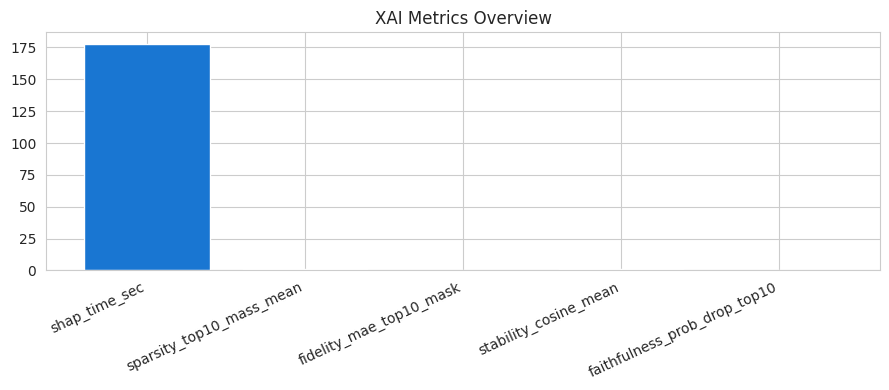

In [12]:
# STEP 4: SHAP analysis metrics (fidelity, stability, sparsity, faithfulness, time)
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

X_sample = XAI_CTX['X_sample']
shap_values = XAI_CTX['shap_values']
feature_names = XAI_CTX['feature_names']

# Sparsity: concentration of contribution mass in top features
abs_sv = np.abs(shap_values)
frac_top10 = np.sum(np.sort(abs_sv, axis=1)[:, -10:], axis=1) / (np.sum(abs_sv, axis=1) + 1e-12)
sparsity_top10_mean = float(np.mean(frac_top10))

# Fidelity: compare model probability change after masking non-top features
proba_full = model.predict_proba(X_sample)[:, 1]
topk = 10
masked = np.zeros_like(X_sample.values)
for r in range(X_sample.shape[0]):
    idx = np.argsort(abs_sv[r])[::-1][:topk]
    masked[r, idx] = X_sample.values[r, idx]
proba_masked = model.predict_proba(masked)[:, 1]
fidelity_mae = float(np.mean(np.abs(proba_full - proba_masked)))

# Stability: SHAP similarity for neighboring samples
sub_n = min(300, X_sample.shape[0])
sub_idx = np.random.choice(X_sample.shape[0], size=sub_n, replace=False)
X_sub = X_sample.iloc[sub_idx].reset_index(drop=True)
sv_sub = shap_values[sub_idx]

dists = np.linalg.norm(X_sub.values[:, None, :] - X_sub.values[None, :, :], axis=2)
np.fill_diagonal(dists, np.inf)
nn = np.argmin(dists, axis=1)

cos_sims = []
for i in range(sub_n):
    a = sv_sub[i]
    b = sv_sub[nn[i]]
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    cos_sims.append(float(np.dot(a, b) / denom))
stability_cos_mean = float(np.mean(cos_sims))

# Faithfulness: remove top-k SHAP features and measure probability drop
ablated = X_sample.values.copy()
for r in range(X_sample.shape[0]):
    idx = np.argsort(abs_sv[r])[::-1][:topk]
    ablated[r, idx] = 0.0
proba_ablated = model.predict_proba(ablated)[:, 1]
faithfulness_drop = float(np.mean(proba_full - proba_ablated))

metrics_df = pd.DataFrame([
    {'metric': 'shap_time_sec', 'value': XAI_CTX.get('shap_time_sec', np.nan)},
    {'metric': 'sparsity_top10_mass_mean', 'value': sparsity_top10_mean},
    {'metric': 'fidelity_mae_top10_mask', 'value': fidelity_mae},
    {'metric': 'stability_cosine_mean', 'value': stability_cos_mean},
    {'metric': 'faithfulness_prob_drop_top10', 'value': faithfulness_drop},
])

print('SHAP analysis metrics:')
print(metrics_df.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.bar(metrics_df['metric'], metrics_df['value'], color=['#1976d2', '#43a047', '#fb8c00', '#8e24aa', '#e53935'])
plt.xticks(rotation=25, ha='right')
plt.title('XAI Metrics Overview')
plt.tight_layout()
plt.show()

XAI_CTX['metrics_df'] = metrics_df



LIME explanation (attack_like) at sampled index 1:
                                                         rule    weight
                                cat__http_version_1.1 <= 0.00  0.436232
                                 cat__service_dce_rpc <= 0.00  0.362992
                                   cat__ssl_resumed_F <= 0.00  0.295974
                                  cat__weird_notice_F <= 0.00  0.257317
cat__ssl_cipher_TLS_ECDHE_RSA_WITH_AES_128_GCM_SHA256 <= 0.00  0.204130
                                   cat__conn_state_REJ > 0.00  0.197229
                         num__http_response_body_len <= -0.01  0.180662
                  cat__weird_name_DNS_RR_unknown_type <= 0.00  0.166893
                                   num__missed_bytes <= -0.01 -0.162183
                                      num__dns_rcode <= -0.21 -0.206949
                                     cat__service_smb <= 0.00 -0.223798
                              cat__ssl_version_TLSv13 <= 0.00 -0.247661


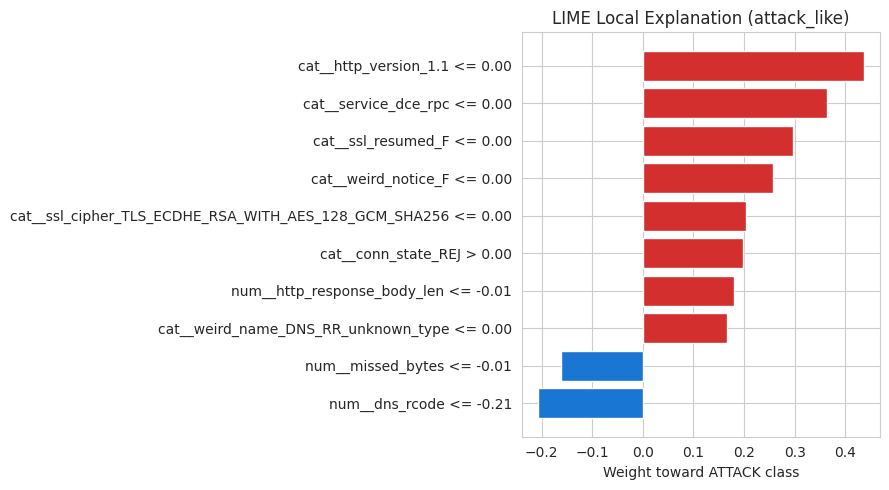


LIME explanation (normal_like) at sampled index 0:
                                                         rule    weight
               cat__ssl_cipher_TLS_AES_128_GCM_SHA256 <= 0.00  0.504092
                                cat__http_version_1.1 <= 0.00  0.416023
                               cat__ssl_established_T <= 0.00  0.339299
                                  cat__weird_notice_F <= 0.00  0.256019
                     cat__weird_name_bad_TCP_checksum <= 0.00  0.224119
                  cat__weird_name_DNS_RR_unknown_type <= 0.00  0.220263
                              cat__service_smb;gssapi <= 0.00 -0.099577
                              cat__http_trans_depth_2 <= 0.00 -0.101094
               cat__weird_name_possible_split_routing <= 0.00 -0.104035
cat__ssl_cipher_TLS_ECDHE_RSA_WITH_AES_128_GCM_SHA256 <= 0.00 -0.139385
                                  cat__service_gssapi <= 0.00 -0.227264
                                        num__dst_port > -0.22 -0.319758


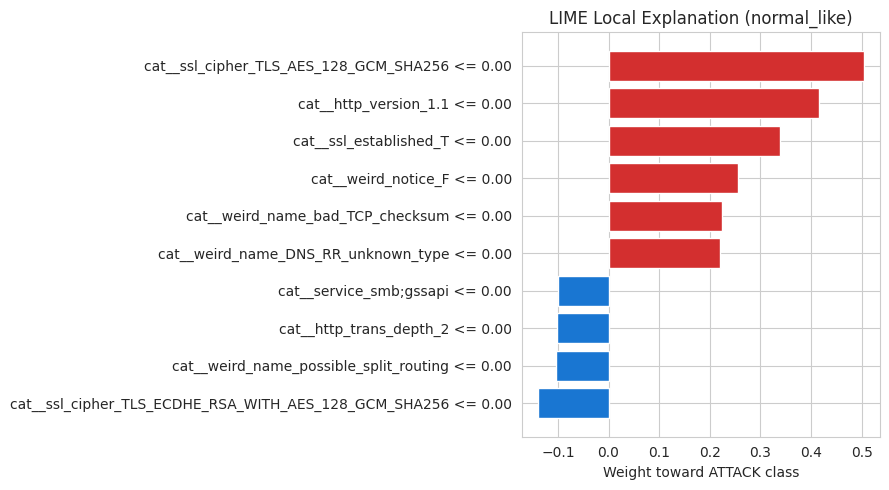


Aggregated LIME rule importance (mean |weight| across explained samples):
                                          rule  abs_weight
cat__ssl_cipher_TLS_AES_128_GCM_SHA256 <= 0.00    0.504092
                 cat__http_version_1.1 <= 0.00    0.426127
                  cat__service_dce_rpc <= 0.00    0.362992
                cat__ssl_established_T <= 0.00    0.339299
                         num__dst_port > -0.22    0.319758
                    cat__ssl_resumed_F <= 0.00    0.295974
                   cat__weird_notice_F <= 0.00    0.256668
               cat__ssl_version_TLSv13 <= 0.00    0.247661
                   cat__service_gssapi <= 0.00    0.227264
      cat__weird_name_bad_TCP_checksum <= 0.00    0.224119
                      cat__service_smb <= 0.00    0.223798
                       num__dns_rcode <= -0.21    0.206949


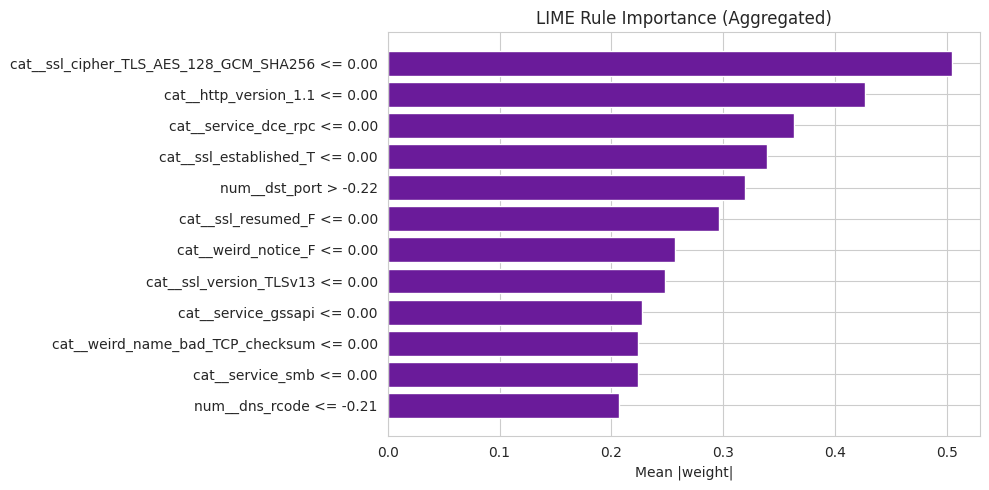

In [13]:
# STEP 5: LIME local explanations + diagrams
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

X_train_df = XAI_CTX['X_train_df']
X_sample = XAI_CTX['X_sample']
feature_names = XAI_CTX['feature_names']

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=feature_names,
    class_names=['normal', 'attack'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

# Explain one predicted attack and one predicted normal sample.
preds = model.predict(X_sample)
attack_ix = np.where(preds == 1)[0]
normal_ix = np.where(preds == 0)[0]
chosen = []
if len(attack_ix) > 0:
    chosen.append(('attack_like', int(attack_ix[0])))
if len(normal_ix) > 0:
    chosen.append(('normal_like', int(normal_ix[0])))
if not chosen:
    chosen.append(('fallback', 0))

lime_rows = []
for tag, idx in chosen:
    exp = lime_explainer.explain_instance(
        X_sample.iloc[idx].values,
        model.predict_proba,
        num_features=12
    )
    pairs = exp.as_list(label=1)

    local_df = pd.DataFrame(pairs, columns=['rule', 'weight']).sort_values('weight', ascending=False)
    print(f'\nLIME explanation ({tag}) at sampled index {idx}:')
    print(local_df.to_string(index=False))

    plt.figure(figsize=(9, 5))
    plot_df = local_df.head(10).iloc[::-1]
    colors = ['#d32f2f' if w > 0 else '#1976d2' for w in plot_df['weight']]
    plt.barh(plot_df['rule'], plot_df['weight'], color=colors)
    plt.title(f'LIME Local Explanation ({tag})')
    plt.xlabel('Weight toward ATTACK class')
    plt.tight_layout()
    plt.show()

    for r, w in pairs:
        lime_rows.append({'sample_tag': tag, 'rule': r, 'weight': float(w)})

lime_df = pd.DataFrame(lime_rows)
agg_lime = (lime_df.assign(abs_weight=lambda d: d['weight'].abs())
                  .groupby('rule', as_index=False)['abs_weight']
                  .mean()
                  .sort_values('abs_weight', ascending=False)
                  .head(12))

print('\nAggregated LIME rule importance (mean |weight| across explained samples):')
print(agg_lime.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(agg_lime['rule'][::-1], agg_lime['abs_weight'][::-1], color='#6a1b9a')
plt.title('LIME Rule Importance (Aggregated)')
plt.xlabel('Mean |weight|')
plt.tight_layout()
plt.show()

XAI_CTX['lime_df'] = lime_df


In [14]:
# STEP 6: Final XAI summary table
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

metrics_df = XAI_CTX.get('metrics_df', pd.DataFrame(columns=['metric', 'value']))
rule_df = XAI_CTX.get('rule_df', pd.DataFrame())
lime_df = XAI_CTX.get('lime_df', pd.DataFrame())

best_rule = None
if len(rule_df) > 0:
    best_rule = rule_df.sort_values(['precision_attack', 'coverage'], ascending=False).iloc[0]

summary_rows = [
    {'item': 'model', 'value': MODEL_NAME if 'MODEL_NAME' in globals() else 'MLP'},
    {'item': 'dataset', 'value': 'TON_IoT'},
    {'item': 'xai_samples_shap', 'value': len(XAI_CTX.get('X_sample', []))},
    {'item': 'shap_top_feature_1', 'value': (XAI_CTX.get('shap_top_features') or ['NA'])[0]},
    {'item': 'lime_rules_collected', 'value': int(len(lime_df))},
]

if best_rule is not None:
    summary_rows.extend([
        {'item': 'best_rule', 'value': best_rule['rule']},
        {'item': 'best_rule_precision_attack', 'value': round(float(best_rule['precision_attack']), 6)},
        {'item': 'best_rule_coverage', 'value': round(float(best_rule['coverage']), 6)},
    ])

for _, r in metrics_df.iterrows():
    summary_rows.append({'item': r['metric'], 'value': round(float(r['value']), 6)})

xai_summary = pd.DataFrame(summary_rows)
print('Final XAI summary:')
print(xai_summary.to_string(index=False))

# Optional save for reporting
xai_summary.to_csv(f"{RESULT_DIR}//{ARTIFACT_NAME}_xai_summary.csv", index=False)
print(f'\nSaved: {RESULT_DIR}//{ARTIFACT_NAME}_xai_summary.csv')


Final XAI summary:
                        item                        value
                       model                          MLP
                     dataset                      TON_IoT
            xai_samples_shap                         1000
          shap_top_feature_1                num__dst_port
        lime_rules_collected                           24
                   best_rule cat__conn_state_REJ > 0.0000
  best_rule_precision_attack                          1.0
          best_rule_coverage                      0.21635
               shap_time_sec                      177.999
    sparsity_top10_mass_mean                     0.832966
     fidelity_mae_top10_mask                     0.179381
       stability_cosine_mean                     0.937384
faithfulness_prob_drop_top10                     0.212462

Saved: /content/drive/MyDrive/MLmodeling/XAI/results/TON_IoT//TON_13_MLP_xai_summary.csv
